#### Notebook 01 — Molecular Representations: From Structural Formulas to Machine-Readable Strings

In the wet lab, we communicate molecular identity through IUPAC names, structural drawings, and CAS numbers. These work well for human chemists — but computers need something more systematic. A structural formula on a whiteboard has no inherent machine-readable encoding, and IUPAC naming, while unambiguous, is verbose and hard to parse programmatically.

This notebook covers the three pillars of computational molecular representation:

1. **SMILES** — compact, human-readable line notation for molecular graphs
2. **InChI / InChIKey** — layered canonical identifiers designed for database deduplication
3. **File formats** (MOL/SDF) — connection tables with coordinates, the digital equivalent of a crystal structure report

We'll use **RDKit** throughout — the open-source cheminformatics toolkit that underpins most computational chemistry workflows in Python.

**Prerequisites**: You should be comfortable with organic structure (bonds, stereochemistry, aromaticity). This notebook bridges your wet-lab intuition to the computational representations, not teaches chemistry from scratch.

## Imports

In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw, AllChem
from rdkit.Chem.inchi import MolFromInchi, MolToInchi, InchiToInchiKey

## SMILES — Simplified Molecular-Input Line-Entry System

SMILES encodes a molecular graph (atoms + bonds) as a linear string. Think of it as a depth-first traversal of the molecular structure, written out as text. If you can draw a molecule, you can read (and eventually write) its SMILES.

### Grammar rules at a glance

| Feature | Syntax | Example | Notes |
|---|---|---|---|
| **Atoms** | Organic subset: `C N O S P F Cl Br I` written bare; everything else in brackets `[...]` | `C` = carbon, `[Fe]` = iron | Bare atoms imply default valence and implicit H |
| **Bonds** | `-` single, `=` double, `#` triple, `:` aromatic | `C=O` = formaldehyde (C=O) | Single bonds are usually omitted |
| **Branches** | Parentheses `()` | `CC(=O)O` = acetic acid | Branch at the second carbon |
| **Rings** | Digit pairs for ring closures | `c1ccccc1` = benzene | Open and close with same digit |
| **Aromaticity** | Lowercase letters = aromatic atoms | `c1ccccc1` vs `C1=CC=CC=C1` | Aromatic SMILES vs Kekule SMILES |
| **Stereochemistry** | `/` `\` for E/Z (cis/trans); `@` `@@` for R/S | `F/C=C/F` = trans-1,2-difluoroethylene | `@` = anticlockwise, `@@` = clockwise (looking from first neighbor) |

### Aromaticity refresher

RDKit uses an aromaticity model rooted in **Huckel's rule**: a planar, cyclic, fully conjugated system with **4n+2 pi electrons** is aromatic. When you write lowercase SMILES (`c1ccccc1`), you're asserting aromaticity. RDKit will verify this claim — if the ring system doesn't satisfy aromaticity criteria, the molecule won't parse.

The alternative is **Kekule SMILES** (`C1=CC=CC=C1`), which explicitly places alternating double bonds. RDKit converts between the two forms internally and always outputs the aromatic form as canonical SMILES for aromatic systems.

### Creating molecules from SMILES

Let's start with two familiar drugs: caffeine and aspirin.

Caffeine SMILES (canonical): Cn1c(=O)c2c(ncn2C)n(C)c1=O


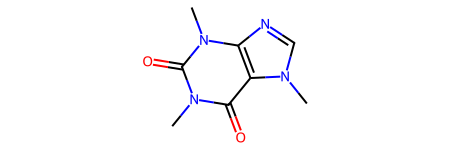

In [2]:
# Caffeine — a purine alkaloid (xanthine derivative)
caffeine = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")
print(f"Caffeine SMILES (canonical): {Chem.MolToSmiles(caffeine)}")
caffeine

Aspirin SMILES (canonical): CC(=O)Oc1ccccc1C(=O)O


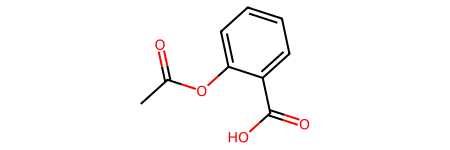

In [3]:
# Aspirin — acetylsalicylic acid
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")
print(f"Aspirin SMILES (canonical): {Chem.MolToSmiles(aspirin)}")
aspirin

### Canonical SMILES — why it matters

The same molecule can be written as many different SMILES strings (different traversal orders). **Canonical SMILES** is RDKit's deterministic normalization — it guarantees that the same molecule always produces the same string. This is critical for database lookups, deduplication, and reproducibility.

In [4]:
# Same molecule (benzene), different SMILES representations
smi_variants = ["c1ccccc1", "C1=CC=CC=C1", "c1ccc(cc1)"]
for smi in smi_variants:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        print(f"{smi:20s} -> canonical: {Chem.MolToSmiles(mol)}")
    else:
        print(f"{smi:20s} -> INVALID (RDKit returned None)")

c1ccccc1             -> canonical: c1ccccc1
C1=CC=CC=C1          -> canonical: c1ccccc1
c1ccc(cc1)           -> canonical: c1ccccc1


### Handling invalid SMILES

`Chem.MolFromSmiles()` returns `None` for unparseable input. Always check the return value before proceeding — this is the single most common source of `AttributeError` in RDKit scripts.

In [5]:
# Invalid SMILES returns None — always guard against this
bad = Chem.MolFromSmiles("not_a_molecule")
print(f"Result: {bad}")  # None

# A defensive pattern you'll use constantly:
smi = "not_a_molecule"
mol = Chem.MolFromSmiles(smi)
if mol is None:
    print(f"Could not parse SMILES: '{smi}'")

Result: None
Could not parse SMILES: 'not_a_molecule'


[22:12:06] SMILES Parse Error: syntax error while parsing: not_a_molecule
[22:12:06] SMILES Parse Error: check for mistakes around position 3:
[22:12:06] not_a_molecule
[22:12:06] ~~^
[22:12:06] SMILES Parse Error: Failed parsing SMILES 'not_a_molecule' for input: 'not_a_molecule'
[22:12:06] SMILES Parse Error: syntax error while parsing: not_a_molecule
[22:12:06] SMILES Parse Error: check for mistakes around position 3:
[22:12:06] not_a_molecule
[22:12:06] ~~^
[22:12:06] SMILES Parse Error: Failed parsing SMILES 'not_a_molecule' for input: 'not_a_molecule'


## SMARTS — Substructure Matching Patterns

SMARTS extends SMILES syntax for **substructure queries**. Think of it as regex for molecules — you define a pattern, and RDKit scans a molecule's graph to find matching atom sets.

This is the computational equivalent of eyeballing a structure and saying "that's a carboxylic acid group." Except SMARTS can do it across millions of molecules in seconds.

Key differences from SMILES:
- SMARTS atoms can specify properties: `[CX3]` means "carbon with 3 connections", `[OX2H1]` means "oxygen with 2 connections and 1 hydrogen"
- Logical operators: `[C,N]` matches C or N; `[!#6]` matches anything except carbon
- We'll do a deep dive in **notebook 04**. For now, let's see the basic idea.

Has carboxylic acid? True
Match atoms (indices): (10, 11, 12)


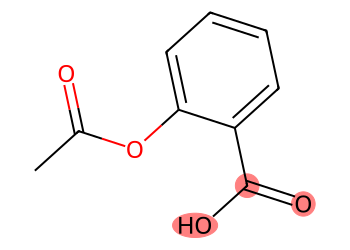

In [6]:
# Find carboxylic acid pattern in aspirin
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

# SMARTS pattern: sp2 carbon with =O and -OH
pattern = Chem.MolFromSmarts("[CX3](=O)[OX2H1]")

print(f"Has carboxylic acid? {aspirin.HasSubstructMatch(pattern)}")
print(f"Match atoms (indices): {aspirin.GetSubstructMatch(pattern)}")

# Highlight the match on the molecule
match_atoms = aspirin.GetSubstructMatch(pattern)
Draw.MolToImage(aspirin, highlightAtoms=match_atoms, size=(350, 250))

## InChI and InChIKey — The IUPAC Standard Identifier

**InChI** (International Chemical Identifier) is IUPAC's answer to the "same molecule, different representation" problem. Unlike SMILES, InChI is strictly canonical by design — there's exactly one InChI per molecule.

### Layer structure

InChI encodes information in **layers**, mirroring the hierarchy chemists use to distinguish isomers:

| Layer | Prefix | What it captures | Analogy |
|---|---|---|---|
| Formula | `/` | Molecular formula | What's in the flask? |
| Connectivity | `/c` | Atom connections (ignoring H) | Draw the skeleton |
| Hydrogen | `/h` | H atom positions | Add the hydrogens |
| Charge | `/q` | Net charge | Check the pH meter |
| Stereochemistry | `/t`, `/b` | Tetrahedral and double-bond stereo | Look at the 3D model |
| Isotope | `/i` | Isotope labels | Labeled compound |

**InChIKey** is a fixed-length 27-character hash of the InChI. It's what you use for database lookups — you can't reconstruct the molecule from an InChIKey, but you can use it for exact-match searches across PubChem, ChEBI, etc.

In [7]:
# Generate InChI and InChIKey for caffeine
caffeine = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")
inchi = MolToInchi(caffeine)
inchi_key = InchiToInchiKey(inchi)

print(f"InChI:    {inchi}")
print(f"InChIKey: {inchi_key}")

# Round-trip: InChI -> Mol -> SMILES
mol_back = MolFromInchi(inchi)
print(f"Round-trip SMILES: {Chem.MolToSmiles(mol_back)}")

InChI:    InChI=1S/C8H10N4O2/c1-10-4-9-6-5(10)7(13)12(3)8(14)11(6)2/h4H,1-3H3
InChIKey: RYYVLZVUVIJVGH-UHFFFAOYSA-N
Round-trip SMILES: Cn1c(=O)c2c(ncn2C)n(C)c1=O


## File Formats — MOL, SDF, and Beyond

While SMILES and InChI are compact string identifiers, sometimes you need **coordinates** — atom positions in 2D or 3D space. This is where file formats come in.

| Format | Extension | Content | Use case |
|---|---|---|---|
| **MOL** (V2000/V3000) | `.mol` | Single molecule with connection table + coordinates | Sharing a structure with coordinates |
| **SDF** | `.sdf` | Multiple MOL blocks + data fields | Compound libraries, vendor catalogs |
| **PDB** | `.pdb` | Protein/macromolecular structures | Docking, structural biology |
| **XYZ** | `.xyz` | Bare coordinates (no bonds) | QM calculations |

Think of a **MOL block** as the digital equivalent of a crystal structure report: it stores every atom, every bond, and where they sit in space. **SDF** files are like a lab notebook — multiple compounds, each with associated data fields (activity, vendor ID, etc.).

In [8]:
# Generate a MOL block for aspirin (with 2D coordinates)
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")
AllChem.Compute2DCoords(aspirin)

mol_block = Chem.MolToMolBlock(aspirin)
print(mol_block[:500])


     RDKit          2D

 13 13  0  0  0  0  0  0  0  0999 V2000
   -3.8123   -1.2868    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.6987   -0.2818    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0122    1.1850    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   -1.2716   -0.7438    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1580    0.2612    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4715    1.7281    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.6420    2


In [9]:
# Round-trip: MOL block -> Mol object -> SMILES
mol_from_block = Chem.MolFromMolBlock(mol_block)
print(f"Round-trip SMILES: {Chem.MolToSmiles(mol_from_block)}")

# Verify it's the same molecule
print(f"Same as original?  {Chem.MolToSmiles(mol_from_block) == Chem.MolToSmiles(aspirin)}")

Round-trip SMILES: CC(=O)Oc1ccccc1C(=O)O
Same as original?  True


## Basic Molecular Properties — Your Computational Data Sheet

Once you have a molecule object, RDKit can compute hundreds of **molecular descriptors** — the computational equivalent of looking up a compound's physical data. Let's compute a few fundamental ones across several well-known molecules.

In [10]:
# Compute basic properties for a set of familiar molecules
molecules = {
    "Caffeine":    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Aspirin":     "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Cholesterol": "CC(C)CCC[C@@H](C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2CC=C4[C@@]3(CC[C@@H](C4)O)C)C",
    "Glucose":     "OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O",
}

for name, smi in molecules.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"WARNING: Could not parse {name} — check SMILES")
        continue
    print(f"\n{name}")
    print(f"  Formula:     {rdMolDescriptors.CalcMolFormula(mol)}")
    print(f"  MW:          {Descriptors.MolWt(mol):.2f}")
    print(f"  Heavy atoms: {mol.GetNumHeavyAtoms()}")
    print(f"  Bonds:       {mol.GetNumBonds()}")
    print(f"  Rings:       {rdMolDescriptors.CalcNumRings(mol)}")


Caffeine
  Formula:     C8H10N4O2
  MW:          194.19
  Heavy atoms: 14
  Bonds:       15
  Rings:       2

Aspirin
  Formula:     C9H8O4
  MW:          180.16
  Heavy atoms: 13
  Bonds:       13
  Rings:       1

Cholesterol
  Formula:     C27H46O
  MW:          386.66
  Heavy atoms: 28
  Bonds:       31
  Rings:       4

Glucose
  Formula:     C6H12O6
  MW:          180.16
  Heavy atoms: 12
  Bonds:       12
  Rings:       1


### Explicit vs. implicit hydrogens

In SMILES and RDKit's default representation, hydrogens are **implicit** — RDKit infers them from valence rules. This keeps things compact but can trip you up when you need accurate atom counts. `Chem.AddHs()` makes all hydrogens explicit; `Chem.RemoveHs()` goes back.

In [11]:
# Explicit vs implicit hydrogens
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

print(f"Heavy atoms: {aspirin.GetNumHeavyAtoms()}")
print(f"Without H:   {aspirin.GetNumAtoms()}")

# Add explicit hydrogens
aspirin_h = Chem.AddHs(aspirin)
print(f"With H:      {aspirin_h.GetNumAtoms()}")

# Remove them again
aspirin_back = Chem.RemoveHs(aspirin_h)
print(f"H removed:   {aspirin_back.GetNumAtoms()}")

Heavy atoms: 13
Without H:   13
With H:      21
H removed:   13


## Summary

In this notebook we covered the foundational representations that bridge bench chemistry to computation:

| Representation | Strengths | Limitations |
|---|---|---|
| **SMILES** | Compact, human-readable, widely supported | Not canonical by default (need RDKit's canonicalization) |
| **SMARTS** | Powerful substructure queries | Steeper learning curve; covered in depth in notebook 04 |
| **InChI / InChIKey** | Strictly canonical, layered structure | Verbose; InChIKey is a one-way hash |
| **MOL/SDF** | Stores coordinates + data fields | Large files; not a string identifier |

**Key takeaways:**
- `Chem.MolFromSmiles()` is your entry point — always check for `None` returns
- Canonical SMILES ensures consistent string comparison across molecules
- InChIKey is your go-to for database deduplication
- `Chem.AddHs()` / `Chem.RemoveHs()` controls hydrogen handling — critical for 3D operations later

**Next up:** Notebook 02 — Molecular Visualization and Drawing with RDKit.